In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('online_retail_sales_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [5]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [7]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [10]:
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Invoice': 'nunique',
    'TotalPrice': 'sum'
})

In [11]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346,326,12,77556.46
12347,2,8,5633.32
12348,75,5,2019.40
12349,19,4,4428.69
12350,310,1,334.40


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [14]:
ss = StandardScaler()
rfm_scaled = ss.fit_transform(rfm)

In [17]:
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertia.append(km.inertia_)

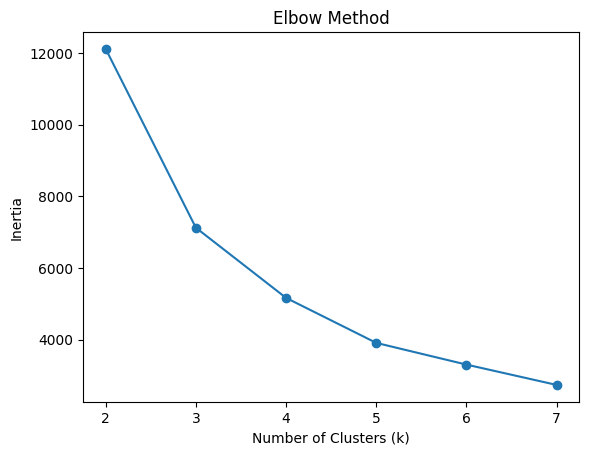

In [18]:
plt.plot(range(2, 8), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [20]:
rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


In [21]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,1998
1,3841
2,35
3,4


In [22]:
cluster_labels = {
    0: 'At Risk',
    1: 'Regular',
    2: 'VIP',
    3: 'Key Accounts (Wholesale/Bulk)'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
Customer ID,,,,,
12346,326,12,77556.46,1,Regular
12347,2,8,5633.32,1,Regular
12348,75,5,2019.40,1,Regular
12349,19,4,4428.69,1,Regular
12350,310,1,334.40,0,At Risk


In [23]:
segment_distribution = rfm['Segment'].value_counts(normalize=True) * 100
print(segment_distribution.round(2))

Segment
Regular                          65.35
At Risk                          33.99
VIP                               0.60
Key Accounts (Wholesale/Bulk)     0.07
Name: proportion, dtype: float64


In [24]:
rfm.to_csv('rfm_segments.csv')